<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Engineering**

В этом курсе вы узнаете об одном из важнейших шагов на пути к созданию отличной модели машинного обучения: проектировании признаков. Вы научитесь:

*   определять, какие признаки являются наиболее важными, используя взаимную информацию;
*   создавать новые признаки в нескольких реальных предметных областях;
кодировать категориальные значения с высокой кардинальностью с помощью целевого кодирования;
*   создавать признаки сегментации с помощью кластеризации k-средних;
*   разлагать вариативность набора данных на признаки с помощью анализа главных компонентов.

Практические упражнения завершатся созданием полного блокнота, в котором все эти методы будут применены для участия в конкурсе House Prices Getting Started. После завершения курса у вас будет несколько идей, которые вы сможете использовать для дальнейшего улучшения своих результатов.

# **Цель разработки функциональных возможностей**
Цель инженерии признаков — просто сделать ваши данные более подходящими для решения поставленной задачи.
Рассмотрим показатели «ощущаемой температуры», такие как индекс жары и ветровое охлаждение. Эти величины пытаются измерить температуру, воспринимаемую человеком, на основе температуры воздуха, влажности и скорости ветра — параметров, которые мы можем измерить напрямую. Можно рассматривать ощущаемую температуру как результат своего рода инженерии признаков, попытку сделать наблюдаемые данные более релевантными тому, что нас действительно волнует: как на самом деле ощущается температура на улице!
Вы можете использовать инженерию признаков для:
*   улучшения прогностической эффективности модели;
*   снижения вычислительных или информационных потребностей;
*   улучшения интерпретируемости результатов.

# **Основной принцип инженерии признаков**

Чтобы признак был полезен, он должен иметь связь с целевым значением, которую ваша модель способна изучить. Линейные модели, например, способны изучать только линейные зависимости. Поэтому при использовании линейной модели ваша цель — преобразовать признаки, чтобы сделать их связь с целевым значением линейной.

Ключевая идея здесь заключается в том, что преобразование, которое вы применяете к признаку, по сути, становится частью самой модели. Допустим, вы пытаетесь предсказать цену квадратных участков земли на основе длины одной стороны. Подгонка линейной модели непосредственно к длине дает плохие результаты: связь не является линейной.
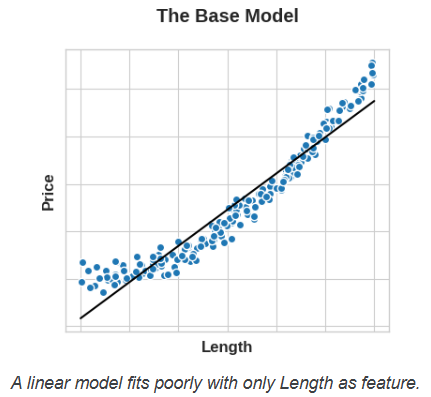

Однако, если мы возведем в квадрат функцию «Длина», чтобы получить «Площадь», мы создадим линейную зависимость. Добавление «Площади» к набору функций означает, что эта линейная модель теперь может аппроксимировать параболу. Другими словами, возведение функции в квадрат дает линейной модели возможность аппроксимировать функции, возведенные в квадрат.

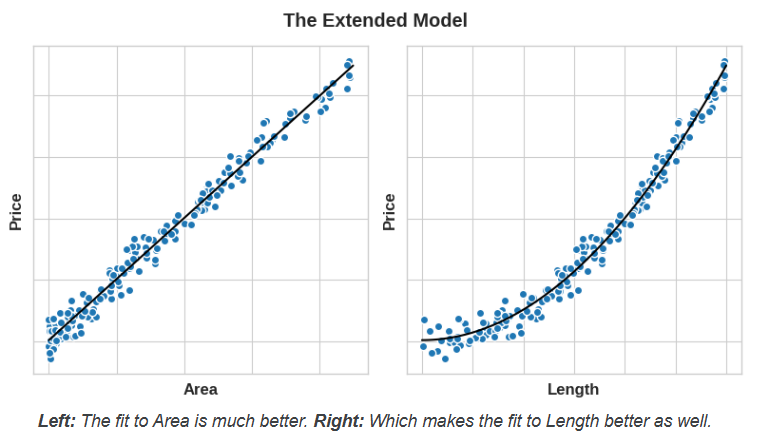

Это должно показать вам, почему время, затраченное на разработку признаков, может быть настолько эффективным. Какие бы взаимосвязи ваша модель не могла изучить самостоятельно, вы можете восстановить их с помощью преобразований. При разработке набора признаков подумайте о том, какую информацию ваша модель могла бы использовать для достижения наилучших результатов.

# **Пример — Состав бетона**

Чтобы проиллюстрировать эти идеи, мы увидим, как добавление нескольких синтетических признаков к набору данных может улучшить прогностическую эффективность модели случайного леса.

Набор данных «Бетон» https://www.kaggle.com/sinamhd9/concrete-comprehensive-strength содержит различные составы бетона и прочность на сжатие полученного продукта, которая является мерой того, какую нагрузку может выдержать данный вид бетона. Задача для этого набора данных — предсказать прочность бетона на сжатие, исходя из его состава.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

url = 'https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/Concrete_Data.csv'
df = pd.read_csv(url, sep=';', decimal=',')
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Здесь вы можете увидеть различные ингредиенты, входящие в состав каждого вида бетона. Через мгновение мы увидим, как добавление некоторых дополнительных синтетических признаков, полученных из этих ингредиентов, может помочь модели изучить важные взаимосвязи между ними.

Сначала мы установим базовый уровень, обучив модель на неаугментированном наборе данных. Это поможет нам определить, действительно ли наши новые признаки полезны.

Установление таких базовых уровней — хорошая практика на начальном этапе процесса проектирования признаков. Базовая оценка может помочь вам решить, стоит ли сохранять ваши новые признаки или следует отбросить их и, возможно, попробовать что-то другое.

In [ ]:
X = df.copy()
y = X.pop('CompressiveStrength')

baseline = RandomForestRegressor(criterion='absolute_error', random_state=0)
baseline_score = cross_val_score(
    baseline, X, y, cv=5, scoring='neg_mean_absolute_error'
)
baseline_score = -1 * baseline_score.mean()

print(f'MAE Baseline Score: {baseline_score:.4}')

MAE Baseline Score: 8.397


Если вы когда-либо готовили дома, вы, вероятно, знаете, что соотношение ингредиентов в рецепте обычно лучше предсказывает конечный результат, чем их абсолютное количество. Таким образом, можно предположить, что соотношения указанных выше характеристик будут хорошим предиктором прочности на сжатие.

Ячейка ниже добавляет в набор данных три новых характеристики соотношения.

In [ ]:
X['FCRatio'] = X['FineAggregate'] / X['CoarseAggregate']
X['AggCmtRatio'] = (X['CoarseAggregate'] + X['FineAggregate']) / X['Cement']
X['WtrCmtRatio'] = X['Water'] / X['Cement']

model = RandomForestRegressor(criterion="absolute_error", random_state=0)
score = cross_val_score(
    model, X, y, cv=5, scoring="neg_mean_absolute_error"
)
score = -1 * score.mean()

print(f"MAE Score with Ratio Features: {score:.4}")

MAE Score with Ratio Features: 8.011


И действительно, производительность улучшилась! Это свидетельствует о том, что новые характеристики соотношения выявили для модели важную информацию, которую она раньше не обнаруживала.

# **Взаимная информация**
# *Найдите объекты с наибольшим потенциалом.*

# Введение
Первое знакомство с новым набором данных иногда может показаться ошеломляющим. Вам могут быть представлены сотни или тысячи признаков без какого-либо описания. С чего же начать?

Отличным первым шагом является построение ранжирования с использованием метрики полезности признаков — функции, измеряющей взаимосвязь между признаком и целевой функцией. Затем вы можете выбрать меньший набор наиболее полезных признаков для первоначальной разработки и быть более уверенными в том, что ваше время будет потрачено с пользой.

Метрика, которую мы будем использовать, называется «взаимная информация». Взаимная информация во многом похожа на корреляцию тем, что измеряет взаимосвязь между двумя величинами. Преимущество взаимной информации заключается в том, что она может обнаруживать любые виды взаимосвязей, в то время как корреляция обнаруживает только линейные зависимости.

Взаимная информация — это отличная универсальная метрика, особенно полезная на начальном этапе разработки признаков, когда вы еще не знаете, какую модель хотите использовать. Она:

*   проста в использовании и интерпретации,
*   вычислительно эффективна,
*   теоретически обоснована,
*   устойчива к переобучению и,
*   способна обнаруживать любые виды взаимосвязей

# **Взаимная информация и что она измеряет**

Взаимная информация описывает взаимосвязи с точки зрения неопределенности. Взаимная информация (ВИ) между двумя величинами — это мера того, насколько знание одной величины уменьшает неопределенность в отношении другой. Если бы вы знали значение характеристики, насколько увереннее вы были бы в отношении целевого значения?

Вот пример из данных Ames Housing. На рисунке показана взаимосвязь между внешним качеством дома и ценой, по которой он был продан. Каждая точка представляет собой дом.

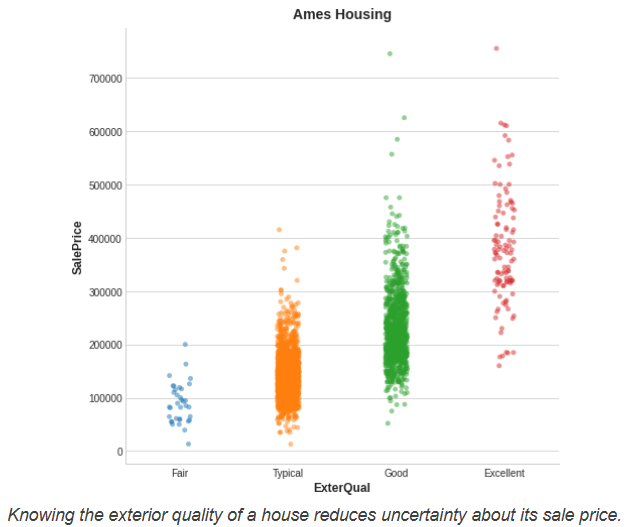

Из рисунка видно, что знание значения ExterQual должно повышать вашу уверенность в соответствующей цене продажи (SalePrice) — каждая категория ExterQual стремится сконцентрировать цену продажи в определенном диапазоне. Взаимная информация, которой обладают ExterQual и SalePrice, представляет собой среднее снижение неопределенности в SalePrice, рассчитанное по четырем значениям ExterQual. Поскольку, например, значение Fair встречается реже, чем Typical, значение Fair получает меньший вес в показателе взаимной информации.

(Техническое примечание: то, что мы называем неопределенностью, измеряется с помощью величины из теории информации, известной как «энтропия». Энтропия переменной примерно означает: «сколько вопросов типа «да» или «нет» вам потребуется задать, чтобы описать возникновение этой переменной в среднем». Чем больше вопросов вам приходится задавать, тем больше неопределенности у вас должно быть в отношении переменной. Взаимная информация — это то, на сколько вопросов, как вы ожидаете, ответит признак относительно целевого значения.)

# **Интерпретация показателей взаимной информации**

Наименьшая возможная взаимная информация между величинами равна 0,0. Когда взаимная информация равна нулю, величины независимы: ни одна из них не может ничего сказать о другой. И наоборот, теоретически нет верхнего предела для того, какой может быть взаимная информация. Однако на практике значения выше 2,0 встречаются редко. (Взаимная информация — это логарифмическая величина, поэтому она увеличивается очень медленно.)

Следующий рисунок даст вам представление о том, как значения взаимной информации соответствуют типу и степени связи признака с целевым объектом.

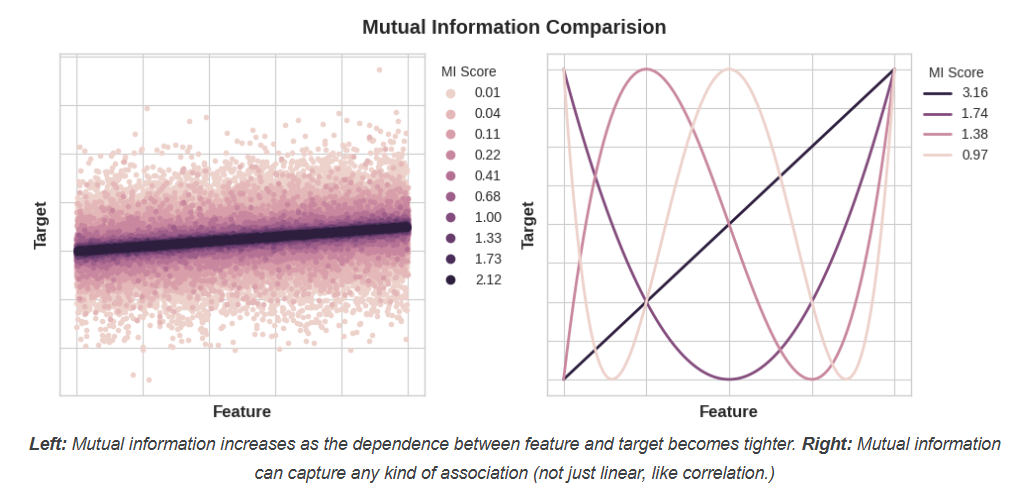

Вот несколько моментов, которые следует помнить при применении взаимной информации:

*   Взаимная информация может помочь вам понять относительный потенциал признака как предиктора целевого значения, рассматриваемого сам по себе.
*   Признак может быть очень информативным при взаимодействии с другими признаками, но не столь информативным сам по себе. Взаимная информация не может обнаружить взаимодействия между признаками. Это одномерная метрика.
*   Фактическая полезность признака зависит от модели, с которой вы его используете. Признак полезен только в той степени, в которой ваша модель может изучить его связь с целевым значением. Высокий показатель взаимной информации не означает, что ваша модель сможет что-либо сделать с этой информацией. Возможно, вам потребуется сначала преобразовать признак, чтобы выявить связь.

# **Пример — Автомобили 1985 года**
Набор данных «Автомобили» https://www.kaggle.com/toramky/automobile-dataset содержит 193 автомобиля 1985 модельного года. Цель этого набора данных — предсказать цену автомобиля (целевой показатель) на основе 23 характеристик автомобиля, таких как марка, тип кузова и мощность. В этом примере мы ранжируем характеристики с помощью взаимной информации и исследуем результаты с помощью визуализации данных.

Ячейка импортирует некоторые библиотеки и загружает набор данных.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/Automobile_data.csv')
df = df.drop('normalized-losses', axis=1)
df = df[~(df == '?').any(axis=1)]
df.head()

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


Алгоритм scikit-learn для обработки множественной информации обрабатывает дискретные признаки иначе, чем непрерывные. Следовательно, необходимо указать, какие из них какие. Как правило, всё, что должно иметь тип данных float, не является дискретным. Категориальные переменные (объектного или категориального типа) можно рассматривать как дискретные, указав для них кодировку метки. (Вы можете ознакомиться с кодировкой меток в нашем уроке по категориальным переменным http://www.kaggle.com/alexisbcook/categorical-variables.)

In [ ]:
X = df.copy()
y = X.pop('price')

# Label encoding for categoricals
for colname in X.select_dtypes('object'):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

В модуле feature_selection библиотеки Scikit-learn есть две метрики взаимной информации: одна для вещественных целевых значений (mutual_info_regression) и одна для категориальных целевых значений (mutual_info_classif). Наше целевое значение, price, является вещественным. В следующей ячейке вычисляются оценки взаимной информации для наших признаков и они объединяются в удобный датафрейм.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

,MI Scores
curb-weight,1.480139
highway-mpg,0.955455
bore,0.693581
wheel-base,0.586207
peak-rpm,0.445455
num-of-cylinders,0.331096
engine-type,0.150524
fuel-type,0.048139


А теперь столбчатая диаграмма для упрощения сравнений:

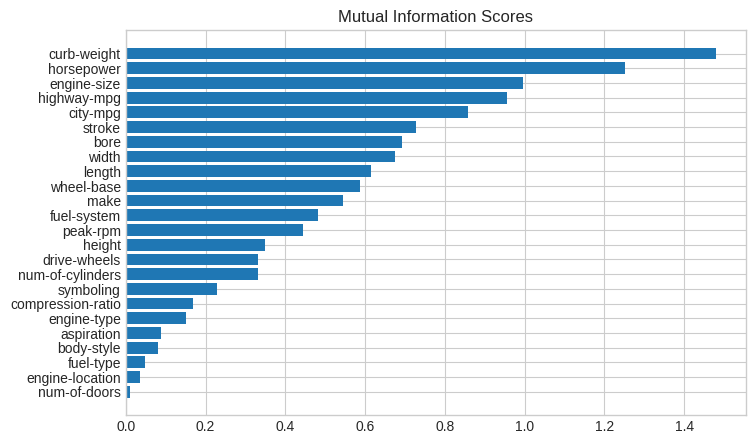

In [ ]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

Визуализация данных — отличное дополнение к рейтингу полезности. Давайте рассмотрим несколько примеров.

Как и следовало ожидать, высоко оцененный показатель curb_weight демонстрирует сильную взаимосвязь с ценой, которая является целевым показателем.

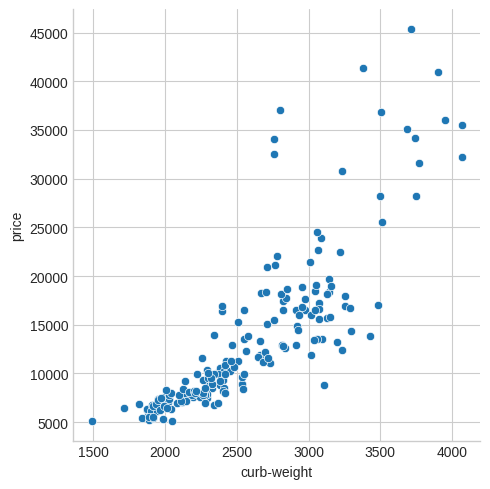

In [ ]:
# Преобразуем столбцы в числовой формат
# errors='coerce' превратит любые нечитаемые значения в NaN (на случай, если там остались другие символы)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Удаляем строки с NaN, которые могли появиться при конвертации
df = df.dropna(subset=['horsepower', 'price'])

sns.relplot(x='curb-weight', y='price', data=df);

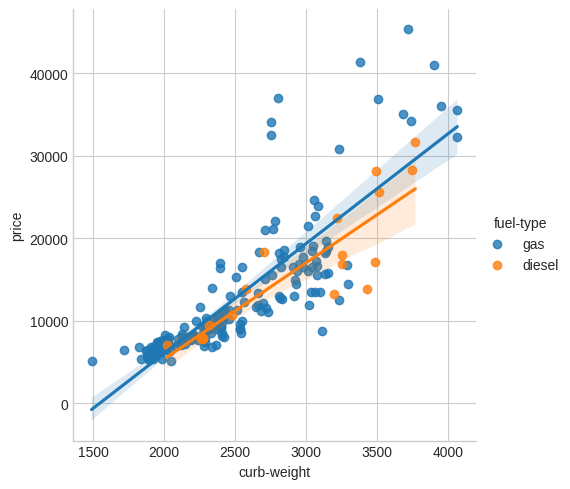

In [ ]:
sns.lmplot(x='curb-weight', y='price', hue='fuel-type', data=df);

Признак fuel_type имеет довольно низкий показатель MI, но, как видно из рисунка, он четко разделяет две группы цен с различными тенденциями в рамках признака мощности. Это указывает на то, что fuel_type вносит эффект взаимодействия и, возможно, все-таки не является неважным. Прежде чем решить, что признак неважен на основании его показателя MI, полезно исследовать любые возможные эффекты взаимодействия — знания предметной области могут здесь оказать большую помощь.

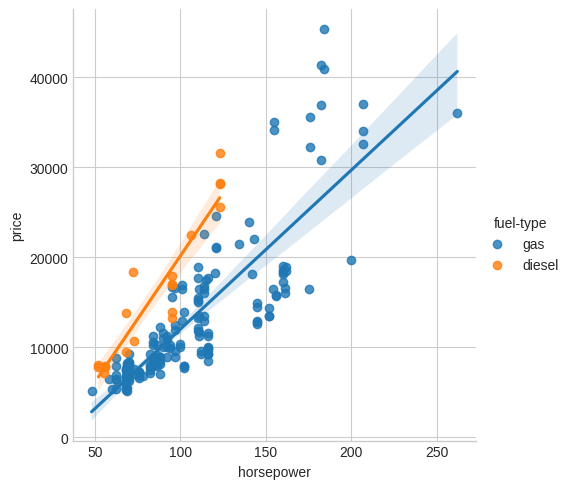

In [ ]:
sns.lmplot(x='horsepower', y='price', hue='fuel-type', data=df);

Визуализация данных — отличное дополнение к вашему инструментарию проектирования признаков. Наряду с такими полезными метриками, как взаимная информация, подобные визуализации могут помочь вам выявить важные взаимосвязи в ваших данных. Узнайте больше, пройдя наш курс по визуализации данных!

# **Домашнее задание**

**Введение**

В этом упражнении вы определите начальный набор признаков в наборе данных Эймса для дальнейшей разработки с использованием оценок взаимной информации и графиков взаимодействия.

Запустите эту ячейку, чтобы все настроить!

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Set Matplotlib defaults
# plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


# Load data
df = pd.read_csv('https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/ames.csv')


# Utility functions from Tutorial
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

Для начала давайте рассмотрим значение взаимной информации на примере нескольких данных из набора данных Эймса.

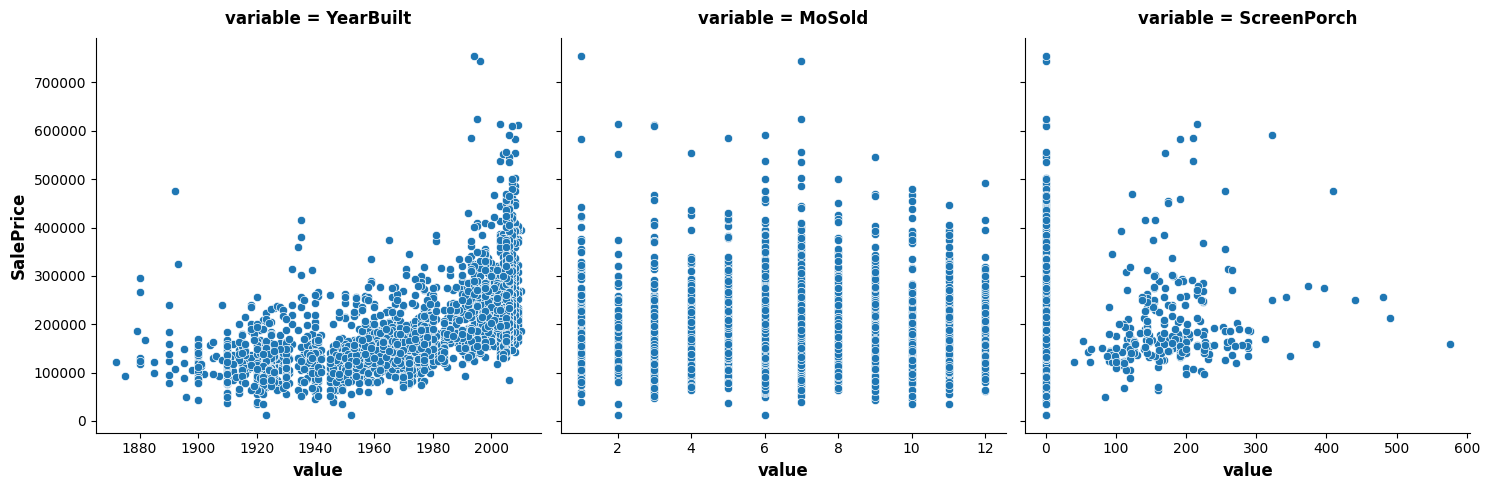

In [ ]:
# 1. Выбираем характеристики дома, которые хотим изучить
features = ["YearBuilt", "MoSold", "ScreenPorch"]

# 2. Рисуем графики зависимости (relplot)
sns.relplot(
    x="value",          # По горизонтали — значения наших характеристик
    y="SalePrice",      # По вертикали — цена продажи дома
    col="variable",     # Создаем отдельную колонку (график) для каждой характеристики

    # 3. Перестраиваем таблицу (melt), чтобы "склеить" выбранные признаки в один столбец.
    # Это нужно библиотеке Seaborn, чтобы она поняла, как разбить данные на три графика.
    data=df.melt(id_vars="SalePrice", value_vars=features),

    # 4. Настройка масштаба: разрешаем каждому графику иметь свою шкалу по оси X.
    # Это важно, так как годы (например, 2000) и месяцы (1-12) нельзя измерять одной линейкой.
    facet_kws=dict(sharex=False),
);

# **1) Understand Mutual Information**
Based on the plots, which feature do you think would have the highest mutual information with SalePrice?

# **Ответ:**
Судя по графикам, YearBuilt должен иметь самый высокий показатель MI, поскольку знание года, как правило, ограничивает диапазон возможных значений SalePrice. Однако для MoSold это обычно не так. Наконец, поскольку ScreenPorch обычно имеет только одно значение, 0, в среднем он мало что скажет о SalePrice (хотя и больше, чем MoSold).

Набор данных Ames содержит семьдесят восемь признаков — очень много информации для одновременной работы! К счастью, вы можете определить признаки с наибольшим потенциалом.

Используйте функцию make_mi_scores (представленную в руководстве) для вычисления оценок взаимной информации для признаков Ames:

In [ ]:
X = df.copy()
y = X.pop('SalePrice')

mi_scores = make_mi_scores(X, y)

Теперь проанализируйте результаты, используя функции в этой ячейке. Обратите особое внимание на верхние и нижние позиции.

OverallQual     0.581262
Neighborhood    0.569813
GrLivArea       0.496909
YearBuilt       0.437939
GarageArea      0.415014
TotalBsmtSF     0.390280
GarageCars      0.381467
FirstFlrSF      0.368825
BsmtQual        0.364779
KitchenQual     0.326194
ExterQual       0.322390
YearRemodAdd    0.315402
MSSubClass      0.287131
GarageFinish    0.265440
FullBath        0.251693
Foundation      0.236115
LotFrontage     0.233334
GarageType      0.226117
FireplaceQu     0.221955
SecondFlrSF     0.200658
Name: MI Scores, dtype: float64


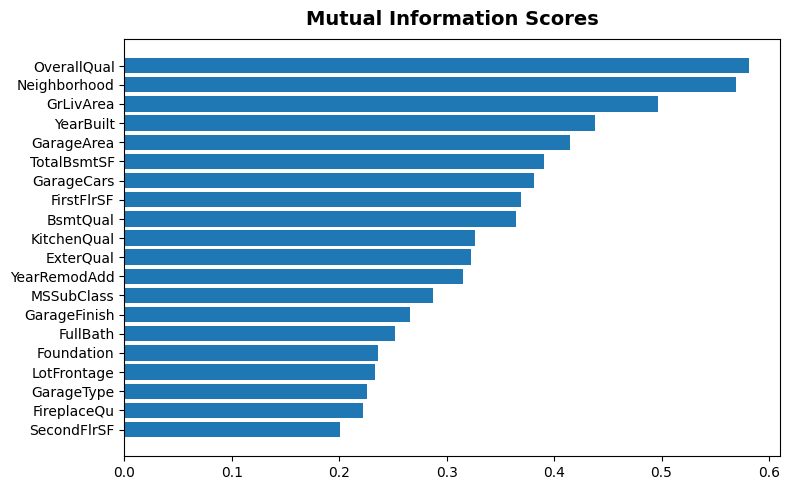

In [ ]:
print(mi_scores.head(20))
# print(mi_scores.tail(20))  # uncomment to see bottom 20

plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores.head(20))
# plot_mi_scores(mi_scores.tail(20))  # uncomment to see bottom 20

# **2) Изучите баллы MI**
Кажутся ли баллы разумными? Отражают ли высокие баллы характеристики, которые, по вашему мнению, большинство людей ценят в доме? Замечаете ли вы какие-либо общие закономерности в их описании?

Некоторые общие черты большинства этих характеристик:

Местоположение: Район
Размер: все характеристики «Площадь» и «Квадратные футы», а также такие показатели, как «Полная ванная комната» и «Гараж на несколько автомобилей»
Качество: все характеристики «Качество»
Год постройки: Год строительства и Год реконструкции/добавления
Типы: описания характеристик и стилей, такие как «Фундамент» и «Тип гаража»
Это все те типы характеристик, которые вы часто будете видеть в объявлениях о недвижимости (например, на Zillow). Хорошо, что наш показатель взаимной информации оценил их высоко. С другой стороны, характеристики с самым низким рейтингом, похоже, в основном представляют собой редкие или исключительные вещи, и поэтому не будут актуальны для среднестатистического покупателя жилья.

На этом этапе вы изучите возможные эффекты взаимодействия для параметра BldgType. Этот параметр описывает общую структуру жилого дома в пяти категориях:

Тип здания (номинальный): Тип жилого дома

1Fam Отдельно стоящий одноквартирный дом
2FmCon Переоборудованный двухквартирный дом; первоначально построен как одноквартирный дом
Duplx Дуплекс
TwnhsE Торцевой таунхаус
TwnhsI Внутренний таунхаус
Параллельный таунхаус
Параллельно BldgType получил не очень высокий балл MI. График подтверждает, что категории в BldgType плохо различают значения в SalePrice (другими словами, распределения выглядят довольно похожими):

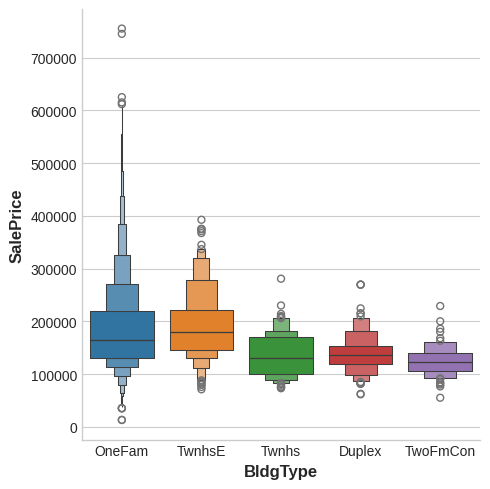

In [ ]:
sns.catplot(
    x="BldgType",
    y="SalePrice",
    data=df,
    kind="boxen",
    hue="BldgType",
    legend=False
);

Тем не менее, тип жилья, кажется, должен быть важной информацией. Исследуйте, оказывает ли параметр BldgType существенное взаимодействие с одним из следующих параметров:

GrLivArea # Площадь надземной части жилого помещения
MoSold # Количество проданных месяцев
Запустите следующую ячейку дважды: первый раз с параметром feature = "GrLivArea", а второй раз с параметром feature="MoSold":

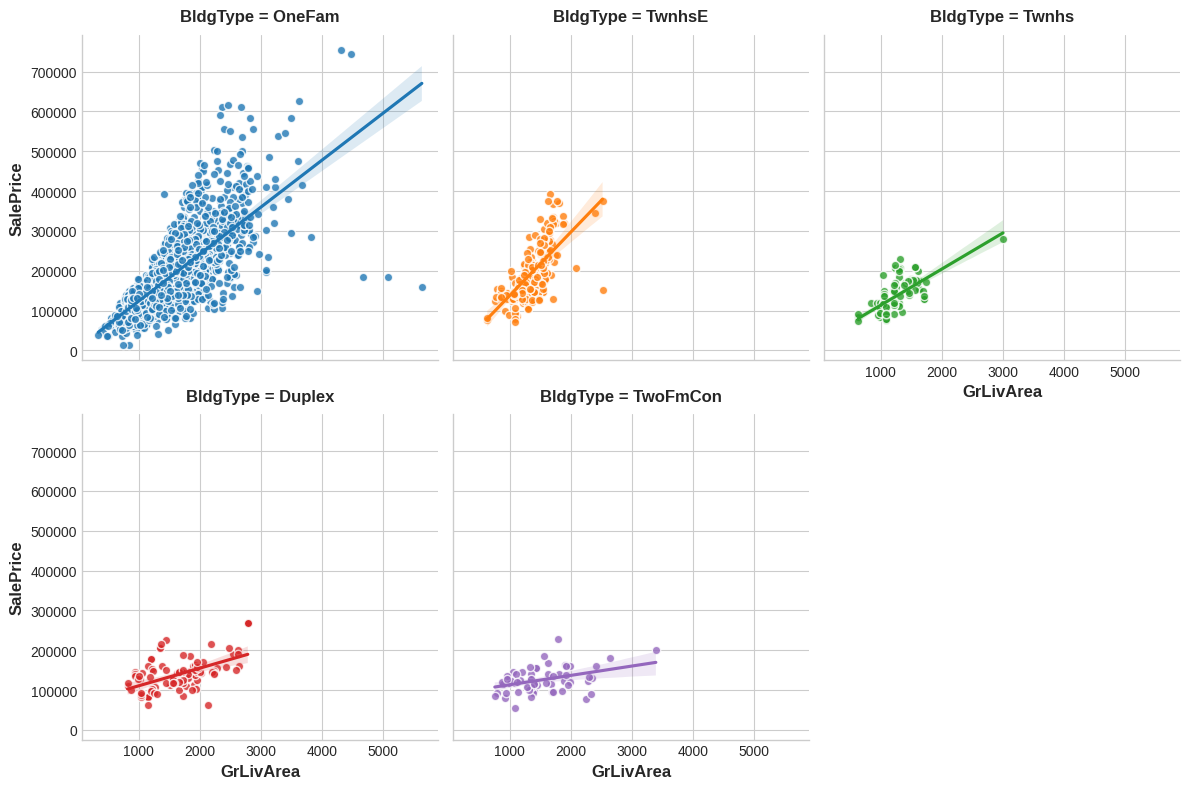

In [ ]:
feature = "GrLivArea"

sns.lmplot(
    x=feature, y="SalePrice", hue="BldgType", col="BldgType",
    data=df, scatter_kws={"edgecolor": 'w'}, col_wrap=3, height=4,
);

Значительные различия в линиях тренда между категориями указывают на эффект взаимодействия.

# **3) Выявление взаимодействий**
Судя по графикам, наблюдается ли взаимодействие между BldgType и GrLivArea или MoSold?

**Ответ:**

Линии тренда внутри каждой категории BldgType явно сильно различаются, что указывает на взаимодействие между этими характеристиками. Поскольку знание BldgType дает нам больше информации о том, как GrLivArea связана с SalePrice, нам следует рассмотреть возможность включения BldgType в наш набор характеристик.

Однако линии тренда для MoSold практически одинаковы. Эта характеристика не стала более информативной при знании BldgType.

# **Первый набор функций для разработки**

Давайте составим список функций, на которых мы могли бы сосредоточиться. В упражнении из Урока 3 вы начнете создавать более информативный набор функций, комбинируя исходные функции, которые вы определили как обладающие высоким потенциалом.

Вы обнаружили, что десять функций с наивысшими показателями MI были:

In [ ]:
mi_scores.head(10)

,MI Scores
OverallQual,0.581262
Neighborhood,0.569813
GrLivArea,0.496909
YearBuilt,0.437939
GarageArea,0.415014
TotalBsmtSF,0.390280
GarageCars,0.381467
FirstFlrSF,0.368825
BsmtQual,0.364779
KitchenQual,0.326194


Узнаёте ли вы здесь основные темы? Местоположение, размер и качество. Вам не обязательно ограничивать разработку только этими главными характеристиками, но теперь у вас есть хорошая отправная точка. Сочетание этих главных характеристик с другими связанными характеристиками, особенно с теми, которые вы определили как создающие взаимодействие, — это хорошая стратегия для создания высокоинформативного набора характеристик для обучения вашей модели.

# **Creating Features**

**Введение**¶

После того, как вы определили набор потенциально перспективных признаков, пришло время начать их разработку. В этом уроке вы изучите ряд распространенных преобразований, которые можно выполнить полностью в Pandas.

В этом уроке мы будем использовать четыре набора данных с различными типами признаков: дорожно-транспортные происшествия в США, автомобили 1985 года, составы бетона и пожизненная ценность клиента. Следующая ячейка загружает их.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# accidents = pd.read_csv("https://doi.org/10.34740/kaggle/ds/199387")
autos = pd.read_csv("https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/Automobile_data.csv")
concrete = pd.read_csv("https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/Concrete_Data.csv", sep=';', decimal=',')
customer = pd.read_csv("https://raw.githubusercontent.com/Grashch/Kaggle_tasks/refs/heads/main/data/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")

**Советы по поиску новых признаков**


*   Поймите признаки. Обратитесь к документации к вашему набору данных, если она доступна.
*   Изучите предметную область, чтобы получить знания в этой области. Если ваша задача — прогнозирование цен на жилье, проведите исследование, например, в сфере недвижимости. Википедия может стать хорошей отправной точкой, но книги и научные статьи часто содержат наиболее полную информацию.
*   Изучите предыдущие работы.
*   Используйте визуализацию данных. Визуализация может выявить отклонения в распределении признака или сложные взаимосвязи, которые можно упростить. Обязательно визуализируйте свой набор данных в процессе разработки признаков.

**Математические преобразования**

Взаимосвязи между числовыми характеристиками часто выражаются с помощью математических формул, с которыми вы будете часто сталкиваться в ходе исследования предметной области. В Pandas вы можете применять арифметические операции к столбцам так же, как если бы это были обычные числа.

В наборе данных «Автомобили» представлены характеристики, описывающие двигатель автомобиля. Исследование позволяет получить множество формул для создания потенциально полезных новых характеристик. Например, «коэффициент хода поршня» — это показатель эффективности двигателя по сравнению с его производительностью:

In [ ]:
# 1. Заменяем '?' на NaN и конвертируем в числа
autos["stroke"] = pd.to_numeric(autos["stroke"], errors='coerce')
autos["bore"] = pd.to_numeric(autos["bore"], errors='coerce')

# 2. Теперь расчет будет работать (NaN / NaN даст NaN, без ошибки)
autos["stroke_ratio"] = autos.stroke / autos.bore

# Проверка результата
autos[["stroke", "bore", "stroke_ratio"]].head()

,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


Чем сложнее комбинация, тем труднее модели будет её обучить, например, формулу для «рабочего объема» двигателя, показателя его мощности:

In [ ]:
# ГЛАВНОЕ: создаем копию из исходного датафрейма в начале ячейки
# (Предположим, исходный df у вас называется df_raw или вы загружаете его заново)
df = autos.copy()

# 1. Конвертируем bore и stroke
df["stroke"] = pd.to_numeric(df["stroke"], errors='coerce')
df["bore"] = pd.to_numeric(df["bore"], errors='coerce')

# 2. Мапим цилиндры (проверяем, что это еще строки, а не числа)
cyl_map = {"two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "eight": 8, "twelve": 12}

if df["num-of-cylinders"].dtype == 'object':
    df["num-of-cylinders"] = df["num-of-cylinders"].str.strip().str.lower().map(cyl_map)

# 3. Очистка
df = df.dropna(subset=["stroke", "bore", "num-of-cylinders"]).copy()

# 4. Смена типа и расчет
df["num-of-cylinders"] = df["num-of-cylinders"].astype(int)
df["displacement"] = (
    np.pi * ((0.5 * df.bore) ** 2) * df.stroke * df['num-of-cylinders']
)

# Перезаписываем рабочую переменную для других ячеек
autos = df
autos[["bore", "stroke", "num-of-cylinders", "displacement"]].head()

,bore,stroke,num-of-cylinders,displacement
0,3.47,2.68,4,101.377976
1,3.47,2.68,4,101.377976
2,2.68,3.47,6,117.446531
3,3.19,3.40,4,108.695147
4,3.19,3.40,5,135.868934


Визуализация данных может подсказать преобразования, часто «изменение формы» характеристики с помощью степеней или логарифмов. Например, распределение скорости ветра в дорожно-транспортных происшествиях в США сильно искажено. В этом случае логарифм эффективно нормализует его:

In [ ]:
# Файл с данными большой!!!
# # Если для параметра заданы значения 0,0, используйте np.log1p (log(1+x)) вместо np.log
# accidents["LogWindSpeed"] = accidents.WindSpeed.apply(np.log1p)

# # Постройте график сравнения
# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# sns.kdeplot(accidents.WindSpeed, shade=True, ax=axs[0])
# sns.kdeplot(accidents.LogWindSpeed, shade=True, ax=axs[1]);

**Результат ячейки:**

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: FutureWarning:

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning:

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  import sys

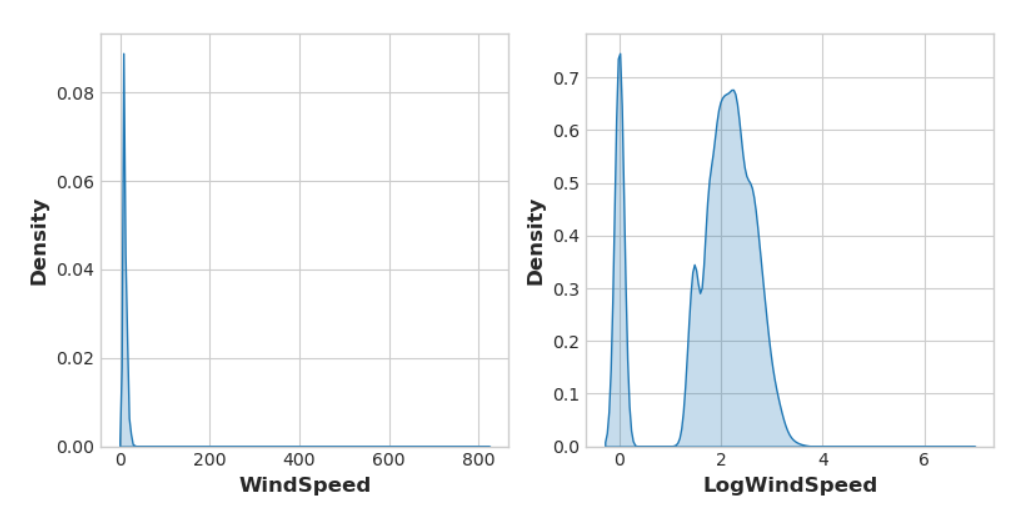

Ознакомьтесь с нашим уроком по нормализации в разделе «Очистка данных», где вы также узнаете о преобразовании Бокса-Кокса — очень общем типе нормализатора.


**Подсчеты**

Признаки, описывающие наличие или отсутствие чего-либо, часто представляют собой наборы, например, набор факторов риска заболевания. Вы можете агрегировать такие признаки, создавая подсчет.

Эти признаки могут быть бинарными (1 — присутствует, 0 — отсутствует) или логическими (истина или ложь). В Python логические значения можно суммировать так же, как и целые числа.

В дорожно-транспортных происшествиях существует несколько признаков, указывающих на то, находился ли какой-либо объект на дороге рядом с местом аварии. Это позволит подсчитать общее количество объектов на дороге поблизости, используя метод суммы:

In [ ]:
# roadway_features = ["Amenity", "Bump", "Crossing", "GiveWay",
#     "Junction", "NoExit", "Railway", "Roundabout", "Station", "Stop",
#     "TrafficCalming", "TrafficSignal"]
# accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1)

# accidents[roadway_features + ["RoadwayFeatures"]].head(10)

Вы также можете использовать встроенные методы датафрейма для создания логических значений. В наборе данных Concrete содержится количество компонентов в рецептуре бетона. Во многих рецептурах отсутствует один или несколько компонентов (то есть, значение компонента равно 0). Это позволит подсчитать, сколько компонентов содержится в рецептуре, используя встроенный метод датафрейма greater-than gt:

In [4]:
components = [ "Cement", "BlastFurnaceSlag", "FlyAsh", "Water",
               "Superplasticizer", "CoarseAggregate", "FineAggregate"]
concrete["Components"] = concrete[components].gt(0).sum(axis=1)

concrete[components + ["Components"]].head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5


**Создание и разбиение элементов данных**

Часто встречаются сложные строки, которые полезно разбить на более простые части. Вот несколько распространенных примеров:

*   Идентификационные номера: '123-45-6789'
*   Номера телефонов: '(999) 555-0123'
*   Адреса улиц: '8241 Kaggle Ln., Goose City, NV'
*   Интернет-адреса: 'http://www.kaggle.com'
*   Коды товаров: '0 36000 29145 2'
*   Даты и время: 'Пн 30 сен 07:06:05 2013'

Подобные элементы данных часто имеют определенную структуру, которую можно использовать. Например, в телефонных номерах США есть код города (часть '(999)'), который указывает местоположение звонящего. Как всегда, здесь полезно провести небольшое исследование.


Метод доступа str позволяет применять строковые методы, такие как split, непосредственно к столбцам. Набор данных Customer Lifetime Value содержит характеристики, описывающие клиентов страховой компании. Из характеристики Policy мы можем разделить Type и Level of coverage:

In [9]:
customer[["Type", "Level"]] = (  # Create two new features
    customer["Policy"]           # from the Policy feature
    .str                         # through the string accessor
    .split(" ", expand=True)     # by splitting on " "
                                 # and expanding the result into separate columns
)

customer[["Policy", "Type", "Level"]].head(10)

,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2
